### Steady state induction motor simulation.
 We aim to produce same results than Quanscient Allsolve demo "https://allsolve.quanscient.com/documentation/learn-by-doing/example-cases/electric-motors/em-002-im-2d"

We use same geometry:

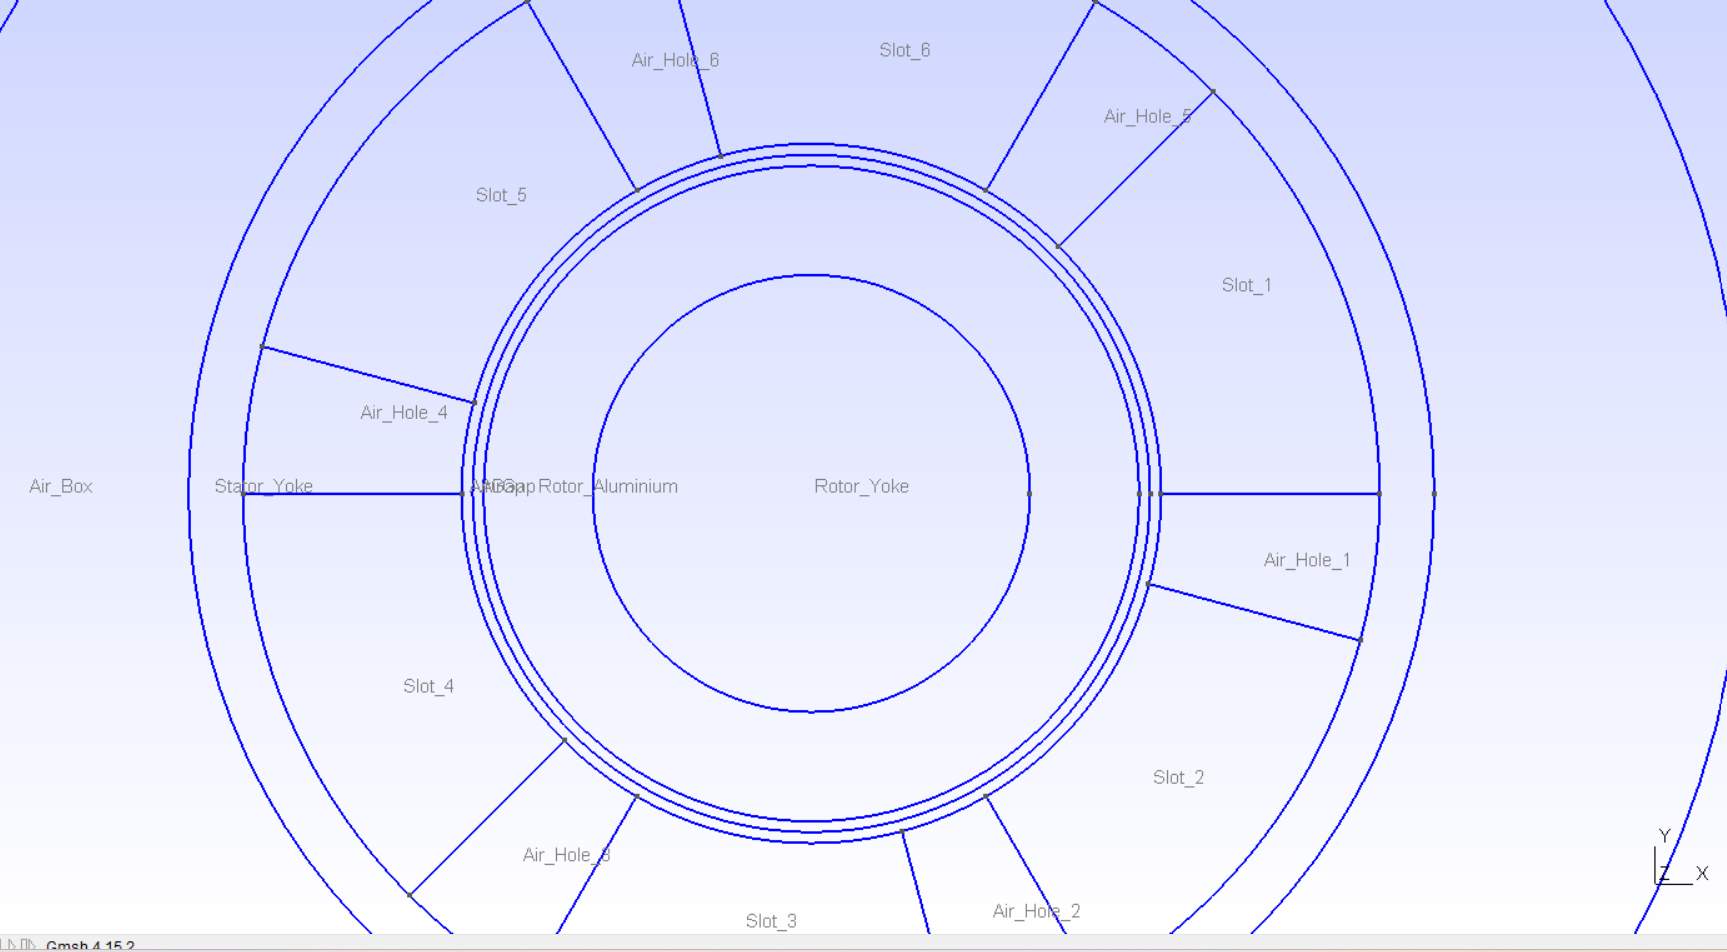

Lets first try to check that our formulation works with solving the torque of 0 rpm case. After that we can start worrying how do we rotate rotor. 

This should results Torque = 3.8259 Nm

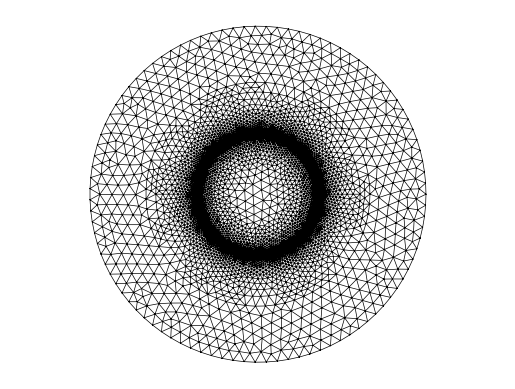

In [1]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

# We have to be careful, the mesh is in mm, but we want to work in SI units (m). So we will scale the mesh by 0.001.
m = meshio.read("mesh/induction_motor.msh")
m.points *= 1e-3  # Scale mesh points from mm to m

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()



In [ ]:
from skfem import Basis, ElementTriP2

e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["Rotor_Yoke"])
basis_rotor_aluminium = basis.with_elements(mesh.subdomains["Rotor_Aluminium"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["Stator_Yoke"])
basis_air_box = basis.with_elements(mesh.subdomains["Air_Box"])
basis_air_holes = basis.with_elements(mesh.subdomains["Air_Hole"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

# Slot to phase current mapping
"""
Slot_1 → A+
Slot_6 → B-
Slot_5 → C+
Slot_4 → A−
Slot_3 → B+
Slot_2 → C−
"""

# Mapping dictionary
slot_bases = {
    name: basis.with_elements(mesh.subdomains[name])
    for name in mesh.subdomains
    if name.startswith("Slot_")
}

# For example Slot_1 → A+
print(slot_bases["Slot_1"])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases["Slot_1"])
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 626
  Number of DOFs: 25130
  Size: 540864 B

In units of m:  0.0006586781367834658


Ampère's law is
 
$$

\nabla \times (\frac{1}{\mu} \nabla \times \mathbf{A})
=
\mathbf{J}_s + \mathbf{J}_e,
$$
 
where
 
- $\mathbf{J}_s$ is stator current,
- $\mathbf{J}_e$ is induced rotor current.

We can use time-harmonic approximation to solve this. We are interested in steady-state conditions,  and it is fair to assume all the fields vary sinusoidally in steady-state (because using sinusoidal currents to drive ethe system.)

$$
\frac{\partial A_z}{\partial t} = j \omega A_z
$$

In general, 

$$
\mathbf{E} = -\frac{\partial A_z}{\partial t} -\nabla V
$$

We can express electric field simply,

$$
\mathbf{E} = -j \omega A_z -\nabla V
$$

and for our induction motor example, we can neglect the voltage term $\nabla V \approx 0$, since the eddy-currents in rotor bars are induced because of magnetic field, not by drived electric potential difference $\nabla V$

The weak form of the magnetoquasistatic frequency-domain problem is


$$

\int_{\Omega}

\frac{1}{\mu} \, \nabla A_z \cdot \nabla v \
 + \int_{\Omega_c} j\omega\sigma A_z v \, d\Omega = \int_{\Omega_s} J_s v \, d\Omega

$$
with Dirichlet BC to surrounding air of A_z = 0 

We assume only rotor aluminium and rotor steel are conducting regions wih $\sigma >> 0 $, so the frequency domain term is only present there. Otherwise the solving is really similar to our previuous tasks

In [57]:
from skfem import Functional

#######
# Material params
#######

sigma_rotor_yoke = 1.6e6  # S/m
sigma_rotor_aluminium = 3.72e7  # S/m

mu0 = 4 * np.pi * 1e-7  # H/m
mu_rotor_yoke = 30 * mu0
mu_stator_yoke = 30 * mu0
current_phase_shift = 0

#######
# Current params
#######

f = 60  # Hz
T = 1/f # s
omega = 2 * np.pi * f  # rad/s
J_0 = 310e4 # A/cm^2  -> A/m^2 

A_phase = 0
B_phase = 2*np.pi/3
C_phase = 4*np.pi/3


######
#  Bilinear and linear forms  :  add dtype=np.complex128 to handle complex numbers!
######

# Stifness matrix 
@BilinearForm
def stiff_lhs(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

# Source currents
@LinearForm(dtype=np.complex128)
def slot_rhs(v, w):
    return w.J * v

# Mass matrix
@BilinearForm(dtype=np.complex128)
def mass_lhs(A, v, w):
    omega = w.omega
    sigma = w.sigma
    return 1j*omega*sigma*A*v

### Assemble left-hand-side

# RotorYoke and StatorYoke are modelled as magnetic iron
S_mat = stiff_lhs.assemble(basis_rotor_yoke, mu=mu_rotor_yoke)
S_mat += stiff_lhs.assemble(basis_stator_yoke, mu=mu_stator_yoke)

# Non magnetic regions have mu = mu0
S_mat += stiff_lhs.assemble(basis_rotor_aluminium, mu=mu0)
S_mat += stiff_lhs.assemble(basis_air_box, mu=mu0)
S_mat += stiff_lhs.assemble(basis_air_holes, mu=mu0)
S_mat += stiff_lhs.assemble(basis_air_gap, mu=mu0)

# Slots (non magnetic air with current density source) are modelled as non magnetic
for slot_basis in slot_bases.values():
    S_mat += stiff_lhs.assemble(slot_basis, mu=mu0)

# Assemble mass matrix term for conducting region Rotor_Yoke and Rotor_Aluminium
M_mat = mass_lhs.assemble(basis_rotor_yoke, omega=omega, sigma = sigma_rotor_yoke)
M_mat += mass_lhs.assemble(basis_rotor_aluminium, omega=omega, sigma = sigma_rotor_aluminium)

lhs = S_mat+M_mat

# Assemble right-hand-side
# Assign 3-phase phasor currents, lets use RMS values
J_A = J_0*np.exp(-1j*A_phase)
J_B = J_0*np.exp(-1j*B_phase)
J_C = J_0*np.exp(-1j*C_phase)
#  slot to phase current mapping:
"""
Slot_1 → A+
Slot_6 → B-
Slot_5 → C+
Slot_4 → A−
Slot_3 → B+
Slot_2 → C−
"""

phase_map = {
    "Slot_1": -J_A,
    "Slot_2": +J_C,
    "Slot_3": -J_B,
    "Slot_4": +J_A,
    "Slot_5": -J_C,
    "Slot_6": +J_B,
}

# Assign current to slot using our dictionary mapping
b = 0
for slot, J in phase_map.items():
    b += slot_rhs.assemble(slot_bases[slot], J=J)

rhs = b

lhs, rhs = enforce(lhs, rhs, D=mesh.boundary_nodes())
A_z = solve(lhs, rhs)

A_real = np.real(A_z)      # Real part
A_imag = np.imag(A_z)      # Imaginary part
A_abs  = np.abs(A_z)       # Magnitude
A_phase = np.angle(A_z)    # Phase (radians)

# Post-processing : Compute Torque with Arkkio's method

L_stack = 1.0        # your machine's axial stack length
airgap_thickess = 2*1e-3 ## 2mm airgap 
@Functional
def arkkio_integrand(w):
    gradA = w['A'].grad  
    Bx = gradA[1]
    By = -gradA[0]

    x, y = w.x                    # global coordinates at quadrature points
    r = np.sqrt(x**2 + y**2)
    
    Br = (x*Bx + y*By) / r
    Bt = (-y*Bx + x*By) / r

    # Return real part of the phasor product Br x Bt*. This is a little unclear part to me how the Arkkio works with complex phasors but lets get back to this :D
    return 0.5*np.real(Br * np.conj(Bt))

integral = arkkio_integrand.assemble(
    basis_air_gap, A=basis_air_gap.interpolate(A_z)
)

torque_arkkio = (L_stack / (mu0 * (airgap_thickess))) * integral

print(f"Torque Arkkio: {torque_arkkio}")


Torque Arkkio: -59.45351057638271


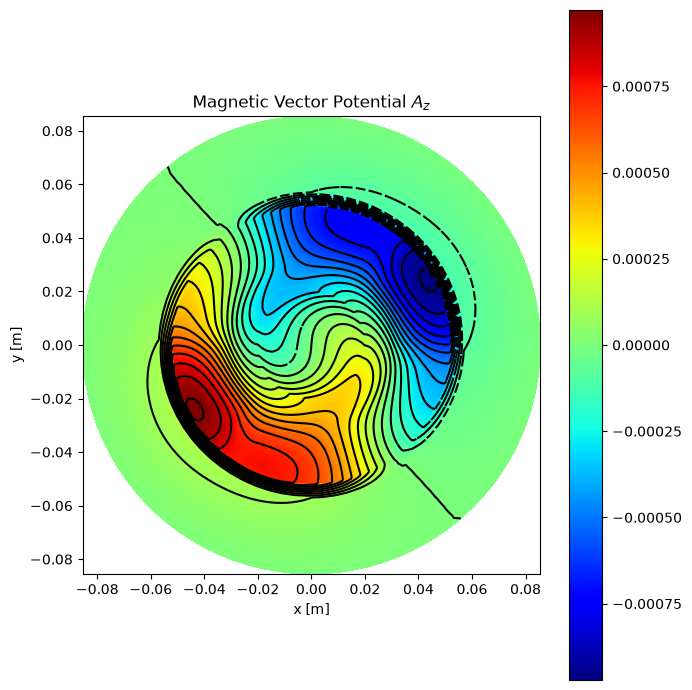

In [65]:
import matplotlib.pyplot as plt
from skfem.visuals.matplotlib import plot

fig, ax = plt.subplots(figsize=(7,7))


plot(
    basis,
    A_real,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

plot(
    basis,
    A_real,
    ax=ax,
    levels=30,
    color="black",
    linewidths=0.4,
)

ax.set_aspect("equal")
ax.set_title(f"Magnetic Vector Potential $A_z$")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.tight_layout()
#from skfem.visuals.matplotlib import draw



plt.show()

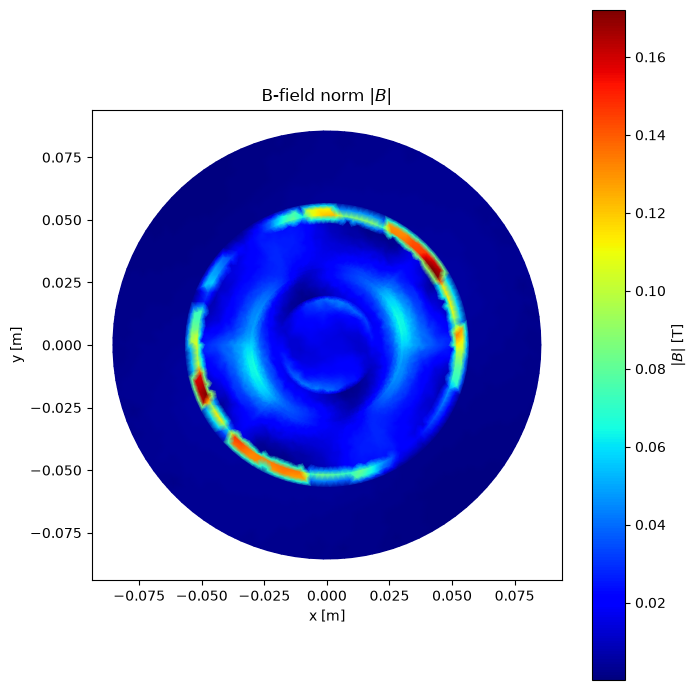

In [64]:
from utils.field_interpolation import elem_to_nodal 

uh = basis.interpolate(A_real)

Bx_elem = uh.grad[1].mean(axis=1)
By_elem = -uh.grad[0].mean(axis=1)

Bmag_elem = np.sqrt(Bx_elem**2 + By_elem**2)

Bmag_nodal = elem_to_nodal(mesh, Bmag_elem)

basis_p1 = Basis(mesh, ElementTriP1())

fig, ax = plt.subplots(figsize=(7,7))

plot(
    basis_p1,
    Bmag_nodal,
    shading="gouraud",
    colorbar=True,
    ax=ax,
)

ax.set_aspect("equal")
ax.set_title(f"B-field norm $|B|$")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

plt.tight_layout()

cbar = fig.axes[-1]
cbar.set_ylabel(r"$|B|$ [T]")

plt.show()

Text(0.5, 1.0, 'B field in stator yoke')

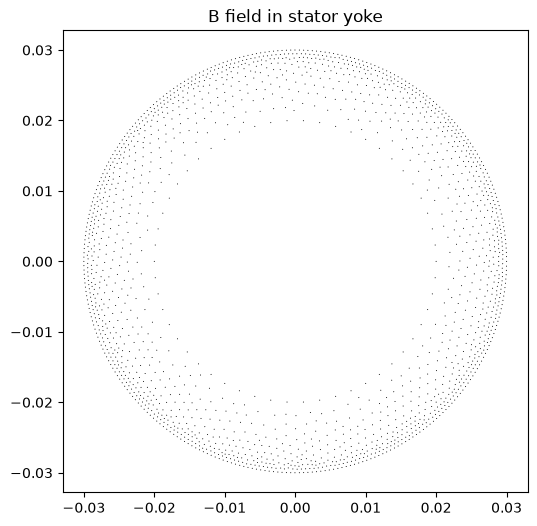

In [ ]:
from utils.field_interpolation import eval_B_at_points

# Elements belonging to the basis
tris = mesh.t[:, basis_rotor_aluminium.tind]

# Unique vertices of those elements
vertex_ids = np.unique(tris)

# Coordinates
pts = mesh.p[:, vertex_ids].T

Bx, By, _ = eval_B_at_points(
    A_abs,
    basis,          # <-- use the FULL basis for evaluation
    pts,
)

plt.figure(figsize=(6,6))
plt.quiver(
    pts[:,0],
    pts[:,1],
    Bx,
    By,
    scale=500
)

plt.axis("equal")
plt.title("B field in stator yoke")